# Overdamped Langevin: X' = X \- \(1/γ\) ∇ U\(X\) Δt \+ σ/γ √\(Δtξ\)

## Dynamics parameters

### Prinz Potential U

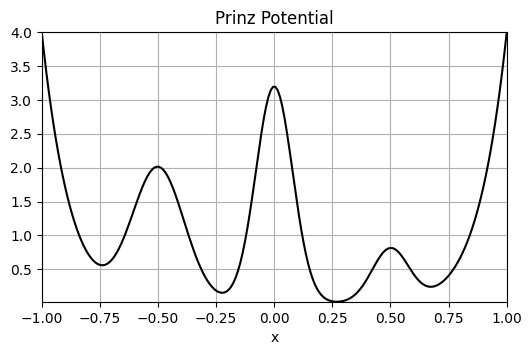

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = [6.0, 3.5]


def prinz_potential(x):
    return 4 * (
        x**8
        + 0.8 * np.exp(-80 * (x**2))
        + 0.2 * np.exp(-80 * ((x - 0.5) ** 2))
        + 0.5 * np.exp(-40 * ((x + 0.5) ** 2))
    )


x = np.linspace(-1, 1, 200)
plt.plot(x, prinz_potential(x), "k")
plt.margins(0)
plt.xlabel("x")
plt.title("Prinz Potential")
plt.grid()


### Inverse temperature 1/σ satisfies β = 2γ/σ², where γ = damping coefficient

So data approximately samples the Boltzmann distribution e^\{\-βV\(x\)\}

Text(0.5, 0, 'x')

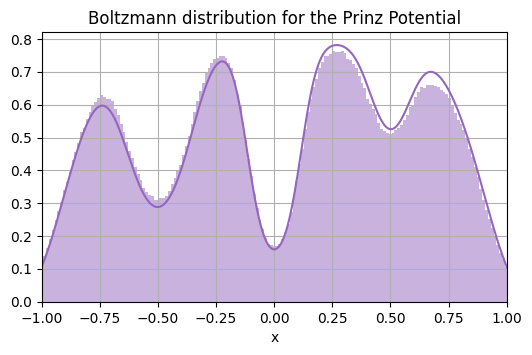

In [ ]:
from scipy.integrate import romb

from kooplearn.datasets import make_prinz_potential

gamma = 1.0
sigma = 2.0
data = make_prinz_potential(X0=0, n_steps=int(5e6), gamma=gamma, sigma=sigma)


def compute_boltzmann_density(x, gamma, sigma):
    beta = 2 * gamma / (sigma**2)
    pdf = np.exp(-beta * prinz_potential(x))
    total_mass = romb(pdf, dx=x[1] - x[0])
    return pdf / total_mass


x = np.linspace(-2, 2, 2048 + 1)
density = compute_boltzmann_density(x, gamma, sigma)
plt.hist(data, bins=200, density=True, alpha=0.5, color="tab:purple")
plt.plot(x, density, color="tab:purple")
plt.xlim(-1, 1)
plt.grid()
plt.title("Boltzmann distribution for the Prinz Potential")
plt.xlabel("x")


<hr>

# Estimating Langevin eigenfunctions

## Classical kernel methods: Transfer operator model \+ RRR vs kDMD

> This is the method for reproducing Kostic et al\. 2023 Figure 2

100%|██████████| 10/10 [03:32<00:00, 21.20s/it]


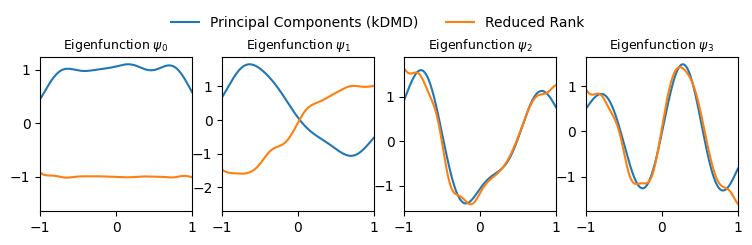

In [ ]:
from collections import defaultdict

from tqdm import tqdm

from kooplearn.datasets import make_prinz_potential
from kooplearn.kernel import KernelRidge

n_train_samples = 5001


def fit_and_estimate(reduced_rank, x, density, random_state):
    subsample = 100  # long trajectories for sampling Boltzmann distribution

    # Parameters of Langevin equation
    data = make_prinz_potential(
        X0=0, n_steps=int(7e5), gamma=gamma, sigma=sigma, random_state=random_state
    )

    # Sample new trajectories
    data = data.iloc[
        ::subsample  # don't need all data
    ]

    data = data[:n_train_samples]

    # Model definition
    model = KernelRidge(
        n_components=5,
        reduced_rank=reduced_rank,
        gamma=12.5,
        kernel="rbf",
        alpha=1e-6,
        random_state=random_state,
    )

    # Fit and estimate eigenfunctions
    model.fit(data)  # fit transfer op model
    values, functions = model.eig(
        eval_right_on=x
    )  # (right) eigenvalue estimation, evaluate on array x
    sort_perm = np.flip(np.argsort(np.abs(values)))  # Order decreasingly
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = normalize_eigenfunctions(functions, x, density)
    return functions


# Compute normalisation constant (∫e(-βV(x))|ψ(x)|^2 dx)^½
def normalize_eigenfunctions(functions, x, density):
    abs2_eigfun = (np.abs(functions) ** 2).T  # f(x)**2
    abs2_eigfun *= density  # Compute the norm with respect to the Boltzmann measure.
    dx = x[1] - x[0]
    funcs_norm = np.sqrt(romb(abs2_eigfun, dx=dx, axis=1))  # Norms
    functions *= funcs_norm**-1.0  # Normalize
    return functions


# Run functions for both RRR (reduced rank) and kDMD (full rank) estimators
dt = 1e-4
n_repetitions = 10  # repeat evaluation
results = defaultdict(list)
for method, reduced_rank in zip(["Principal Components (kDMD)", "Reduced Rank"], [False, True]):
    for i in tqdm(range(n_repetitions)):
        results[method].append(fit_and_estimate(reduced_rank, x[:, None], density, i))

# Print results
fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
for fun_id, ax in enumerate(axs):
    for method, functions in results.items():
        color = "tab:blue" if "Principal" in method else "tab:orange"
        ax.plot(x, functions[0][:, fun_id], color=color, label=method)
    ax.set_title(rf"Eigenfunction $\psi_{fun_id}$", fontsize=9)
    ax.set_xlim(-1, 1)
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncols=2,
    frameon=False,
    bbox_to_anchor=(0.0, 1.05, 1.0, 0.102),
)


> Results show some sign mismatch because spectral decomposition is not unique\.

### Compare against reference eigenvalues \(= ground truth\)

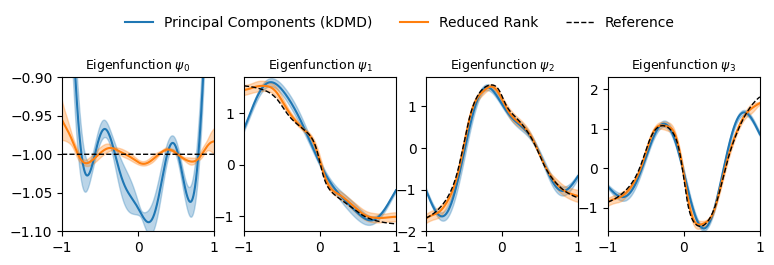

In [ ]:
from kooplearn.datasets import compute_prinz_potential_eig


# Function to standardise the sign of the eigenfunctions
def standardize_sign(eigenfunction, reference, x):
    eigenfunction_cut = cut_functions_to_domain(eigenfunction, x)
    reference_cut = cut_functions_to_domain(reference, x)
    norm_p = np.linalg.norm(eigenfunction_cut + reference_cut)
    norm_m = np.linalg.norm(eigenfunction_cut - reference_cut)
    if norm_p <= norm_m:
        return -1.0 * eigenfunction
    else:
        return eigenfunction


# use prinz to get reference eigenfunctions for comparison
dt = data.attrs["params"]["dt"]
_, reference_eigfuns = compute_prinz_potential_eig(
    gamma, sigma, dt, eval_right_on=x, num_components=5
)
reference_eigfuns = normalize_eigenfunctions(reference_eigfuns, x, density)


# Function to fit eigenfunctions to domain of references
def cut_functions_to_domain(functions, x, x_lims=(-1, 1)):
    mask = (x >= x_lims[0]) & (x <= x_lims[1])
    return functions[mask]


def compute_ylims(reference, margin=0.1):
    ref_min = reference.min()
    ref_max = reference.max()
    if ref_min < 0:
        ref_min *= 1 + margin
    else:
        ref_min *= 1 - margin
    if ref_max < 0:
        ref_max *= 1 - margin
    else:
        ref_max *= 1 + margin

    y_min = np.round(ref_min, 1)
    y_max = np.round(ref_max, 1)
    return y_min, y_max


def plot_eigenfunctions_with_uncertainty(results, reference_eigfuns, x):
    tab_colors = plt.get_cmap("tab10").colors
    fig, axs = plt.subplots(ncols=4, figsize=(9, 2))
    for fun_id, ax in enumerate(axs):
        reference = reference_eigfuns[:, fun_id]
        for color, (method, functions) in zip(tab_colors, results.items()):
            # Standardize signs according to the reference
            functions = np.array(functions)  # Convert list of arrays into array
            n_repetitions = functions.shape[0]
            for i in range(n_repetitions):
                for j in range(4):
                    functions[i, :, j] = standardize_sign(
                        functions[i, :, j], reference_eigfuns[:, j], x
                    )
            m = functions.mean(0)[:, fun_id].real
            st = functions.std(0)[:, fun_id].real
            ax.plot(x, m, color=color, label=method)
            ax.fill_between(x, m - st, m + st, color=color, alpha=0.3)
            ax.set_ylim(compute_ylims(reference))
        ax.plot(x, reference, color="k", lw=1, ls="--", label="Reference")
        ax.set_title(rf"Eigenfunction $\psi_{fun_id}$", fontsize=9)
        ax.set_xlim(-1, 1)
    handles, labels = ax.get_legend_handles_labels()
    ncols = 2 if (len(results) + 1) == 4 else 3
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncols=ncols,
        frameon=False,
        bbox_to_anchor=(0.0, 1.15, 1.0, 0.102),
    )


plot_eigenfunctions_with_uncertainty(results, reference_eigfuns, x)


> RRR approximates better than kDMD

## Representation learning method: encoder\-only model \+ SpectralContrastiveLoss

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

from kooplearn.linear_model import Ridge
from kooplearn.torch.nn import SpectralContrastiveLoss
from kooplearn.torch.utils import FeatureMapEmbedder

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 512

# Set up
n_train_samples = 5000
n_val_samples = 1000

subsample = 100
data = make_prinz_potential(X0=0, n_steps=int(7e5), gamma=gamma, sigma=sigma, random_state=0)
data = data.iloc[
    ::subsample  # don't need all data
]

# Training script
train_data = torch.from_numpy(data[:n_train_samples].values).float()
val_data = torch.from_numpy(data[-n_val_samples:].values).float()

# Creating PyTorch TensorDatasets
train_ds = TensorDataset(train_data[:-1], train_data[1:])
val_ds = TensorDataset(val_data[:-1], val_data[1:])

# Creating DataLoaders
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)

# Experiment hyperparameters
learning_rate = 1e-2
opt = torch.optim.AdamW
num_epochs = 200
layer_dims = [32, 64, 32]
latent_dim = 32
random_state = 42


# Layer 1 = Encoder: A Multilayer Perceptron (MLP) that lifts the state to the latent space.
class SimpleMLP(torch.nn.Module):
    def __init__(self, latent_dim: int, layer_dims: list[int], activation=torch.nn.SiLU):
        super().__init__()
        self.activation = activation
        lin_dims = [1] + layer_dims + [latent_dim]

        layers = []

        for layer_idx in range(len(lin_dims) - 2):
            layers.append(torch.nn.Linear(lin_dims[layer_idx], lin_dims[layer_idx + 1], bias=False))
            layers.append(activation())

        layers.append(torch.nn.Linear(lin_dims[-2], lin_dims[-1], bias=True))

        self.layers = torch.nn.ModuleList(layers)

    def forward(self, x):
        # MLP
        for layer in self.layers:
            x = layer(x)
        return x


# Layer 2 = Predictor: A linear layer that evolves the state forward in time.
class FeatureMap(torch.nn.Module):
    def __init__(self, latent_dim: int, normalize_latents: bool = False):
        super().__init__()
        self.normalize_latents = normalize_latents
        self.backbone = SimpleMLP(latent_dim=latent_dim, layer_dims=layer_dims)
        self.lin = torch.nn.Linear(latent_dim, latent_dim, bias=False)

    def forward(self, X, lagged: bool = False):
        z = self.backbone(X)
        if self.normalize_latents:
            z = torch.nn.functional.normalize(z, dim=-1)
        if lagged:
            z = self.lin(z)
        return z


def train_encoder_only(criterion: torch.nn.Module):
    torch.manual_seed(random_state)
    # Initialize model, loss and optimizer
    model = FeatureMap(latent_dim).to(device)
    optimizer = opt(model.parameters(), lr=learning_rate)

    def step(batch, is_train: bool = True):
        batch_X, batch_Y = batch
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        if is_train:
            optimizer.zero_grad()
        phi_X, phi_Y = model(batch_X), model(batch_Y, lagged=True)
        loss = criterion(phi_X, phi_Y)
        if is_train:
            loss.backward()
            optimizer.step()
        return loss.item()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = []
        for batch in train_dl:
            train_loss.append(step(batch))
        # Validation phase
        model.eval()
        val_loss = []
        with torch.no_grad():
            for batch in val_dl:
                val_loss.append(step(batch, is_train=False))

        if (epoch + 1) % 10 == 0 or epoch == 0:
            train_m = np.mean(train_loss)
            val_m = np.mean(val_loss)
            print(f"EPOCH {epoch + 1:>2}  Loss: {train_m:.2f} (train) - {val_m:.2f} (val)")

    embedder = FeatureMapEmbedder(encoder=model, device=device)
    evolution_operator_model = Ridge(n_components=latent_dim).fit(
        embedder.transform(train_data), train_data.numpy(force=True)
    )

    return {
        "model": evolution_operator_model,
        "feature_map": embedder.transform,
    }


# Learn representations with Spectral Contrastive Loss
trained_models = {}
trained_models["Spectral Contrastive Loss"] = train_encoder_only(SpectralContrastiveLoss())


/tmp/ipykernel_5083/355737849.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_data = torch.from_numpy(data[:n_train_samples].values).float()
EPOCH  1  Loss: -0.85 (train) - -1.81 (val)
EPOCH 10  Loss: -2.01 (train) - -2.17 (val)
EPOCH 20  Loss: -2.51 (train) - -2.44 (val)
EPOCH 30  Loss: -2.55 (train) - -2.55 (val)
EPOCH 40  Loss: -2.96 (train) - -2.93 (val)
EPOCH 50  Loss: -3.01 (train) - -2.96 (val)
EPOCH 60  Loss: -2.99 (train) - -2.89 (val)
EPOCH 70  Loss: -3.06 (train) - -3.00 (val)
EPOCH 80  Loss: -3.08 (train) - -3.02 (val)
EPOCH 90  Loss: -3.08 (train) - -3.00 (val)
EPOCH 100  Loss: -3.04 (train) 

### Compare against ground truth

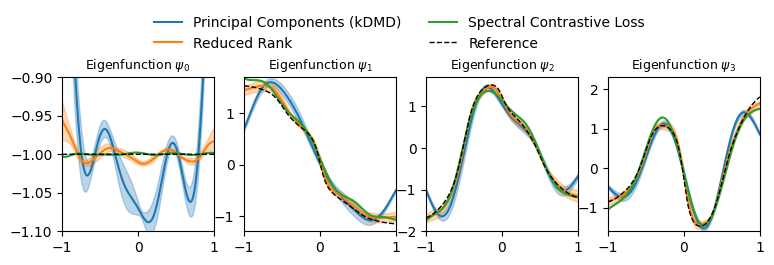

In [ ]:
# Compare against reference eigenvalues as before
def estimate_representations(model, embedder, x, density):
    values, functions = model.eig(eval_right_on=embedder(x))  # Eigenvalue estimation
    sort_perm = np.flip(np.argsort(np.abs(values)))  # Order eigenvalues decreasingly
    values, functions = values[sort_perm], functions[:, sort_perm]
    functions = normalize_eigenfunctions(functions, x, density)
    return functions


for model_id, trained_model in trained_models.items():
    results[model_id] = [
        estimate_representations(
            trained_model["model"], trained_model["feature_map"], x[:, None], density
        )
    ]

plot_eigenfunctions_with_uncertainty(results, reference_eigfuns, x)


> SCL optimising improves precision – notice flat trivial Ψ0 

<hr>

## Generator learning methods: evolution operator model \+ Kernels vs Energy Loss

### infinitesimal generator ℒ 

> ℒ f\(x\) = \- 1/γ ∇V\(x\) · ∇ f\(x\) \+ β/γ Δf\(x\)

= instantaneous evolution of smooth functions in stochastic systems; they encode the evolution of observables \+ key for analysing: 

- long\-time dynamics, 

- metastable states, and 

- spectral properties of system\.

Eigenfunctions of ℒ = directions in function space that evolve exponentially under Koopman operator: 

> K^tφ = e^\{λt\}φ; ℒφ = λφ

### Resolvent \(μI \- ℒ\)^\{\-1\} method – Kostic et al\. 2024

100%|██████████| 10/10 [19:55<00:00, 119.57s/it]


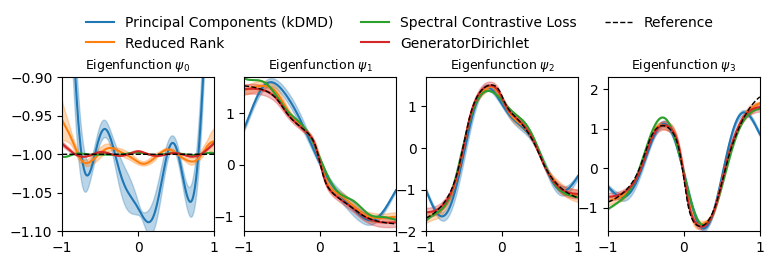

In [ ]:
from kooplearn.kernel._generator import GeneratorDirichlet


def fit_and_estimate_generator(x, density):
    # Same setup as before
    subsample = 100
    gamma = 1.0
    sigma = 2.0
    data = make_prinz_potential(X0=0, n_steps=int(5e5), gamma=gamma, sigma=sigma)
    data = data.values[
        ::subsample  # reduce cost
    ]

    # Model definition
    model = GeneratorDirichlet(
        diffusion=sigma / gamma, n_components=5, gamma=50, alpha=1e-5, shift=5
    )

    # Fit and estimate as before
    model.fit(data)
    values, functions = model.eig(eval_right_on=x)  # Eigenvalue estimation
    values, functions = values, functions
    functions = normalize_eigenfunctions(functions, x, density)
    return functions


results["GeneratorDirichlet"] = []
for _ in tqdm(range(n_repetitions)):
    results["GeneratorDirichlet"].append(fit_and_estimate_generator(x[:, None], density))

# Visualise results
plot_eigenfunctions_with_uncertainty(results, reference_eigfuns, x)


### Energy loss method – learn approximation instead of prescribed kernel \(NN \+ rep learning\)

EPOCH  1  Loss: -1.26 (train) - -1.83 (val)
EPOCH 10  Loss: -2.89 (train) - -2.80 (val)
EPOCH 20  Loss: -2.94 (train) - -2.95 (val)
EPOCH 30  Loss: -3.82 (train) - -3.76 (val)
EPOCH 40  Loss: -4.65 (train) - -4.56 (val)
EPOCH 50  Loss: -5.39 (train) - -5.33 (val)
EPOCH 60  Loss: -5.59 (train) - -5.52 (val)
EPOCH 70  Loss: -6.47 (train) - -6.50 (val)
EPOCH 80  Loss: -7.03 (train) - -6.86 (val)
EPOCH 90  Loss: -7.10 (train) - -6.37 (val)
EPOCH 100  Loss: -7.19 (train) - -7.04 (val)
EPOCH 110  Loss: -7.29 (train) - -7.18 (val)
EPOCH 120  Loss: -7.53 (train) - -7.46 (val)
EPOCH 130  Loss: -8.42 (train) - -8.34 (val)
EPOCH 140  Loss: -8.34 (train) - -8.34 (val)
EPOCH 150  Loss: -8.68 (train) - -8.48 (val)
EPOCH 160  Loss: -8.58 (train) - -8.30 (val)
EPOCH 170  Loss: -8.88 (train) - -8.79 (val)
EPOCH 180  Loss: -9.19 (train) - -9.21 (val)
EPOCH 190  Loss: -9.29 (train) - -9.24 (val)
The rank attribute has been updated to 21.
Consider decreasing the rank parameter.
EPOCH 200  Loss: -9.29 (tra

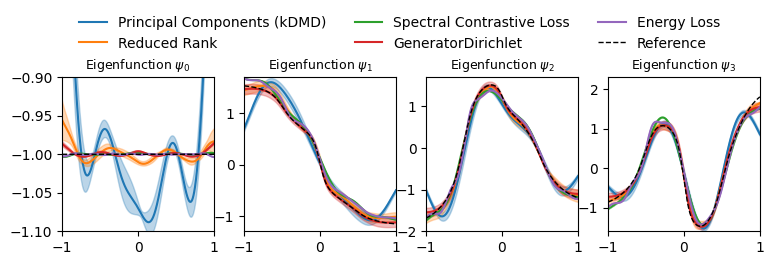

In [ ]:
# Fitting analogous to SCL method

from torch.func import functional_call, jacrev, vmap
from torch.utils.data import DataLoader, TensorDataset

from kooplearn.torch.nn import EnergyLoss

batch_size = 512

# Creating PyTorch TensorDatasets
train_ds = TensorDataset(train_data[:-1])
val_ds = TensorDataset(val_data[:-1])

# Creating DataLoaders
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds), shuffle=False)


class GeneratorFeatureMap(torch.nn.Module):
    def __init__(self, latent_dim: int, layer_dims: list[int], normalize_latents: bool = False):
        super().__init__()
        self.normalize_latents = normalize_latents
        self.backbone = SimpleMLP(latent_dim=latent_dim, layer_dims=layer_dims)

    def compute_jacobian(self, x):
        """
        Efficiently computes the Jacobian of the output embeddings w.r.t the input x.

        This method uses `torch.func.vmap` and `torch.func.jacrev` to compute
        gradients. This is significantly faster than loop-based approaches and
        more memory-efficient than `torch.autograd.functional.jacobian` for batches.

        Parameters
        ----------
        x : torch.Tensor
            Input data of shape (batch_size, latent_dim).

        Returns
        -------
        torch.Tensor
            Jacobian tensor of shape (batch_size, latent_dim, output_dim).

            The element at index [b, i, j] corresponds to the partial derivative:
            $\\frac{\\partial \\text{output}[b, j]}{\\partial \\text{input}[b, i]}$
        """

        # Define a functional version of the forward pass for a single sample
        def func_forward(x_sample, params_buffers):
            out = functional_call(self.backbone, params_buffers, (x_sample,))
            if self.normalize_latents:
                out = torch.nn.functional.normalize(out, dim=-1)
            return out

        # Extract parameters/buffers (needed for functional_call)
        params = dict(self.backbone.named_parameters())
        buffers = dict(self.backbone.named_buffers())
        params_buffers = {**params, **buffers}

        # Compose vmap and jacrev
        # jacrev computes Jacobian of func_forward w.r.t arg 0 (x_sample)
        # vmap vectorizes this operation over the batch dimension (dim 0)
        compute_batch_jacobian = vmap(jacrev(func_forward, argnums=0), in_dims=(0, None))

        # Execute
        jacobian = compute_batch_jacobian(x, params_buffers)

        # jacrev returns (output_dim, input_dim).
        # Since we are mapping R^d -> R^l, jacrev gives dU/dx.
        # Check shapes: resulting shape from vmap is (batch, output_dim, input_dim)
        # You wanted (batch, input_dim, output_dim), so we transpose.
        return jacobian.permute(0, 2, 1)

    def forward(self, x, return_grad: bool = False):
        # Standard forward pass
        z = self.backbone(x)
        if self.normalize_latents:
            z = torch.nn.functional.normalize(z, dim=-1)

        if return_grad:
            jacobian = self.compute_jacobian(x)
            return z, jacobian
        return z


def train_encoder_only(criterion: torch.nn.Module):
    torch.manual_seed(random_state)
    # Initialize model, loss and optimizer
    model = GeneratorFeatureMap(latent_dim, layer_dims).to(device)
    optimizer = opt(model.parameters(), lr=learning_rate)

    def step(batch, is_train: bool = True):
        X = batch[0]
        X = X.to(device)
        if is_train:
            optimizer.zero_grad()
        phi_X, grad_phi_X = model(X, return_grad=True)
        loss = criterion(phi_X, grad_phi_X)
        if is_train:
            loss.backward()
            optimizer.step()
        return loss.item()

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = []
        for batch in train_dl:
            train_loss.append(step(batch))
        # Validation phase
        model.eval()
        val_loss = []
        for batch in val_dl:
            val_loss.append(step(batch, is_train=False))

        if (epoch + 1) % 10 == 0 or epoch == 0:
            train_m = np.mean(train_loss)
            val_m = np.mean(val_loss)
            print(f"EPOCH {epoch + 1:>2}  Loss: {train_m:.2f} (train) - {val_m:.2f} (val)")

    embedder = FeatureMapEmbedder(encoder=model, device=device)
    evolution_operator_model = Ridge(n_components=latent_dim).fit(
        embedder.transform(train_data), train_data.numpy(force=True)
    )

    return {
        "model": evolution_operator_model,
        "feature_map": embedder.transform,
    }


trained_models["Energy Loss"] = train_encoder_only(EnergyLoss(grad_weight=1e-3))

results["Energy Loss"] = [
    estimate_representations(
        trained_models["Energy Loss"]["model"],
        trained_models["Energy Loss"]["feature_map"],
        x[:, None],
        density,
    )
]

# Visualise results
plot_eigenfunctions_with_uncertainty(results, reference_eigfuns, x)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e789536a-7ca4-43e1-b614-a20256eb698b' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>